In [1]:
import pandas as pd

# load the clean dataset
df = pd.read_csv("description_data.csv")

print("Rows:", len(df))
print(df.columns)

Rows: 522
Index(['Id', 'Title', 'Episodes', 'Year', 'Original channel',
       'American company', 'Note', 'Technique', 'IMDb', 'Google users',
       'wiki_title', 'wiki_short_description', 'wiki_summary', 'wiki_url',
       'wiki_status'],
      dtype='object')


In [2]:
# clean summaries
df = df[
    df["wiki_summary"].notna() &
    (df["wiki_summary"].astype(str).str.strip() != "")
].copy()

df = df.reset_index(drop=True)

print("Clean rows:", len(df))

Clean rows: 522


In [3]:
# convert summaries to TF-IDF vectors
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["wiki_summary"])

print(tfidf_matrix.shape)

(522, 5455)


In [4]:
# compute cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(tfidf_matrix)

print(similarity_matrix.shape)

(522, 522)


In [5]:
# return top 10 most similar shows to a query show
def get_top_similar(title, df, sim_matrix, top_n=10):

    if title not in df["Title"].values:
        print(f"{title} not found in dataset")
        return None

    idx = df.index[df["Title"] == title][0]

    scores = list(enumerate(sim_matrix[idx]))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    scores = [x for x in scores if x[0] != idx][:top_n]

    results = pd.DataFrame({
        "Query": title,
        "Similar_Show": [df.iloc[i]["Title"] for i, score in scores],
        "Similarity_Score": [score for i, score in scores]
    })

    return results

In [ ]:
# get random sample
print(df["Title"].sample(20))

480             The Further Adventures of SuperTed
384                                   Duck & Goose
378                                 Dream Corp LLC
127                                  Batman Beyond
248                              Capt'n Sailorbird
401                                  Dogs in Space
96                   The Adventures of Napkin Man!
101                                     Alma's Way
102    The Amazing Colossal Adventures of WordGirl
271                                   Centaurworld
398                                      Dinky Dog
434                             Fanboy & Chum Chum
444                                  Felix the Cat
32              The Adventures of OG Sherlock Kush
306                        The Croods: Family Tree
485                               G.I. Joe Extreme
518                                     Turbo Teen
207                 Barbie: Life in the Dreamhouse
229                             The Bravest Knight
310                   The Cyani

In [14]:
# run similarity queries
q1 = get_top_similar("Curious George (2006)", df, similarity_matrix)
print(q1)

                   Query                                Similar_Show  \
0  Curious George (2006)                        George of the Jungle   
1  Curious George (2006)                           George and Martha   
2  Curious George (2006)               Attack of the Killer Tomatoes   
3  Curious George (2006)  The Cat in the Hat Knows a Lot About That!   
4  Curious George (2006)                            Fantastic Voyage   
5  Curious George (2006)                        Back at the Barnyard   
6  Curious George (2006)                               Dogs in Space   
7  Curious George (2006)                        Ada Twist, Scientist   
8  Curious George (2006)         Bozo: The World's Most Famous Clown   
9  Curious George (2006)                                 Beetlejuice   

   Similarity_Score  
0          0.134235  
1          0.121609  
2          0.111763  
3          0.097683  
4          0.080776  
5          0.075709  
6          0.071018  
7          0.068683  
8        

In [15]:
q2 = get_top_similar("Barbie: Life in the Dreamhouse", df, similarity_matrix)
print(q2)

                            Query                     Similar_Show  \
0  Barbie: Life in the Dreamhouse     Barbie Dreamhouse Adventures   
1  Barbie: Life in the Dreamhouse             Barbie: It Takes Two   
2  Barbie: Life in the Dreamhouse                  Apollo Gauntlet   
3  Barbie: Life in the Dreamhouse                       BraveStarr   
4  Barbie: Life in the Dreamhouse                        Dinozaurs   
5  Barbie: Life in the Dreamhouse                Extreme Dinosaurs   
6  Barbie: Life in the Dreamhouse  The Adventures of Puss in Boots   
7  Barbie: Life in the Dreamhouse                     Dick Figures   
8  Barbie: Life in the Dreamhouse               The Creature Cases   
9  Barbie: Life in the Dreamhouse                     Cita's World   

   Similarity_Score  
0          0.405306  
1          0.341703  
2          0.126600  
3          0.114086  
4          0.112695  
5          0.102020  
6          0.098773  
7          0.094273  
8          0.092699  
9        

In [27]:
q3 = get_top_similar("WordWorld", df, similarity_matrix)
print(q3)

       Query                                   Similar_Show  Similarity_Score
0  WordWorld     The Cat in the Hat Knows a Lot About That!          0.130523
1  WordWorld                    Daniel Tiger's Neighborhood          0.105889
2  WordWorld                  Fox's Peter Pan & the Pirates          0.103219
3  WordWorld            Britannica's Tales Around the World          0.100980
4  WordWorld                             Blaster's Universe          0.093547
5  WordWorld                            Gary and His Demons          0.087176
6  WordWorld  The Adventures of Don Coyote and Sancho Panda          0.085454
7  WordWorld                                    Auto-B-Good          0.080021
8  WordWorld                                     Alma's Way          0.078730
9  WordWorld                Betsy's Kindergarten Adventures          0.078495


In [28]:
q4 = get_top_similar("The Flintstones", df, similarity_matrix)
print(q4)

             Query                     Similar_Show  Similarity_Score
0  The Flintstones       The Flintstone Comedy Hour          0.261673
1  The Flintstones   Fred and Barney Meet the Thing          0.229077
2  The Flintstones   Fred and Barney Meet the Shmoo          0.173767
3  The Flintstones                       Baby Blues          0.173489
4  The Flintstones              The Flintstone Kids          0.166972
5  The Flintstones                      Dino Babies          0.164525
6  The Flintstones  The Boss Baby: Back in Business          0.154062
7  The Flintstones                         Big Baby          0.148547
8  The Flintstones      Fred Flintstone and Friends          0.136207
9  The Flintstones       The Flintstone Comedy Show          0.135792


In [69]:
q5 = get_top_similar("The Batman", df, similarity_matrix)
print(q5)

        Query                    Similar_Show  Similarity_Score
0  The Batman                         Ant-Man          0.483132
1  The Batman                   Batman Beyond          0.388762
2  The Batman     Batman: The Animated Series          0.376454
3  The Batman                         Aquaman          0.345503
4  The Batman  The All-New Super Friends Hour          0.254447
5  The Batman  Batman: The Brave and the Bold          0.228464
6  The Batman      DC Super Hero Girls (2019)          0.222965
7  The Batman        The Batman/Superman Hour          0.221707
8  The Batman                DC Nation Shorts          0.221407
9  The Batman        The Adventures of Batman          0.217244


In [70]:
q6 = get_top_similar("Dora the Explorer", df, similarity_matrix)
print(q6)

               Query                      Similar_Show  Similarity_Score
0  Dora the Explorer  Dora and Friends: Into the City!          0.283792
1  Dora the Explorer               Blue's Clues & You!          0.173544
2  Dora the Explorer                Face's Music Party          0.164175
3  Dora the Explorer                 Ask the StoryBots          0.150344
4  Dora the Explorer                           Baymax!          0.149647
5  Dora the Explorer                            The 7D          0.140953
6  Dora the Explorer                      Glitch Techs          0.140386
7  Dora the Explorer              Back at the Barnyard          0.132832
8  Dora the Explorer                   The Casagrandes          0.130125
9  Dora the Explorer                 Ben 10: Omniverse          0.126245


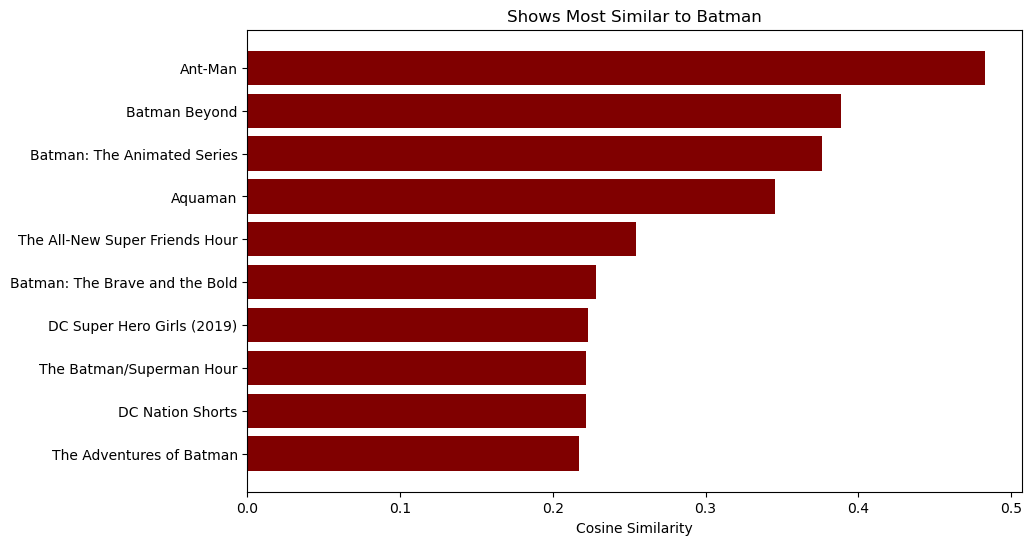

In [71]:
import matplotlib.pyplot as plt

# visualization in a bar chart
plt.figure(figsize=(10,6))
plt.barh(q5["Similar_Show"], q5["Similarity_Score"], color = "maroon")
plt.xlabel("Cosine Similarity")
plt.title("Shows Most Similar to Batman")
plt.gca().invert_yaxis()
plt.show()

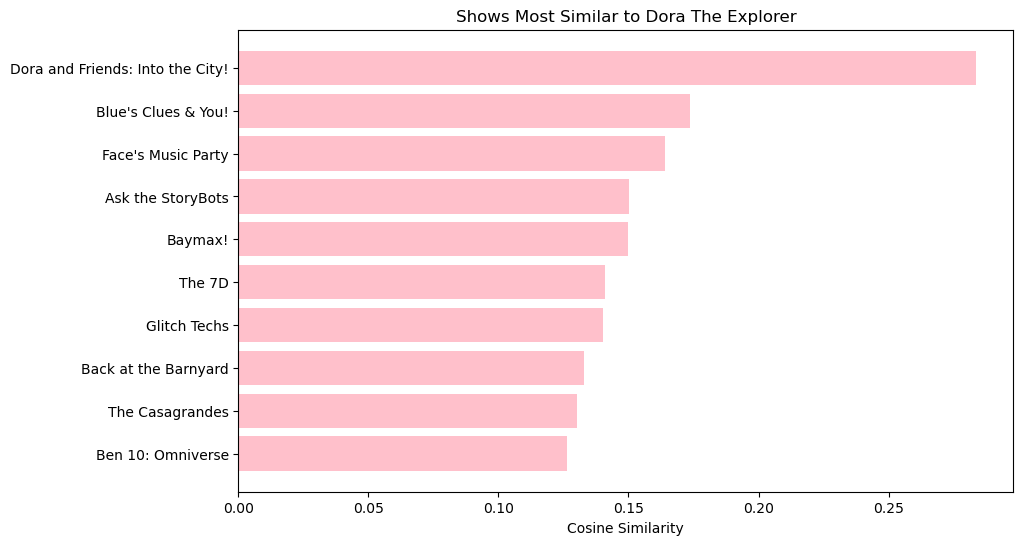

In [72]:
plt.figure(figsize=(10,6))
plt.barh(q6["Similar_Show"], q6["Similarity_Score"], color = "pink")
plt.xlabel("Cosine Similarity")
plt.title("Shows Most Similar to Dora The Explorer")
plt.gca().invert_yaxis()
plt.show()

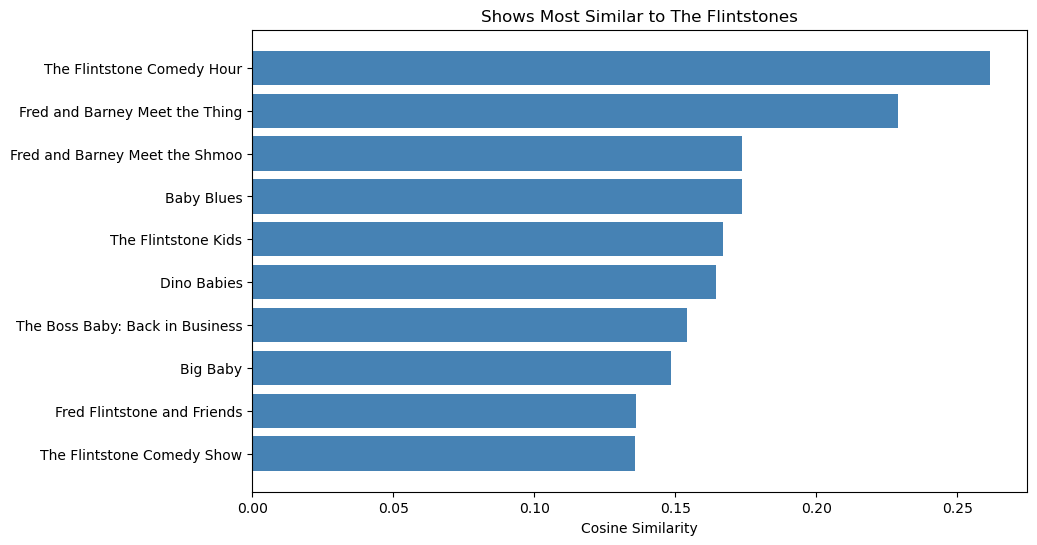

In [73]:
plt.figure(figsize=(10,6))
plt.barh(q4["Similar_Show"], q4["Similarity_Score"], color = "steelblue")
plt.xlabel("Cosine Similarity")
plt.title("Shows Most Similar to The Flintstones")
plt.gca().invert_yaxis()
plt.show()

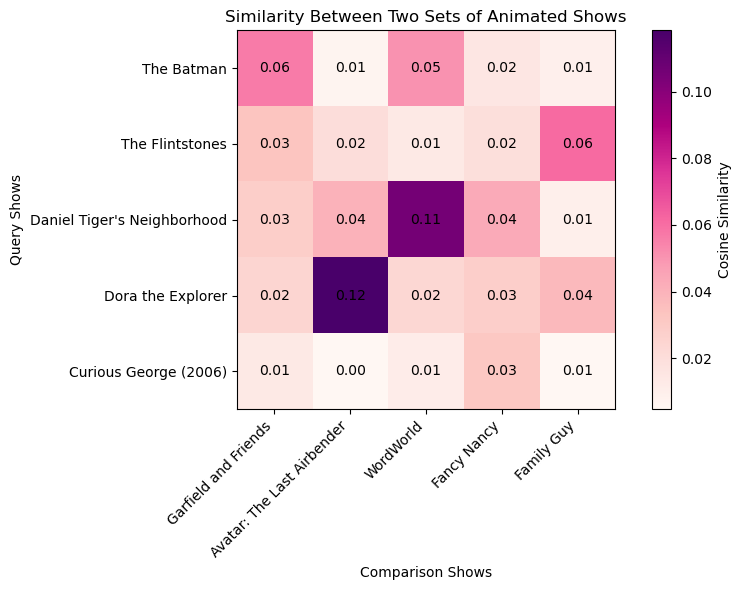

In [ ]:
# 5x5 cross-similarity heatmap

import numpy as np
import matplotlib.pyplot as plt

# choose 5 shows for Y-axis
y_shows = [
    "The Batman",
    "The Flintstones",
    "Daniel Tiger's Neighborhood",
    "Dora the Explorer",
    "Curious George (2006)"
]

# choose 5 shows for X-axis
x_shows = [
    "Garfield and Friends",
    "Avatar: The Last Airbender",
    "WordWorld",
    "Fancy Nancy",
    "Family Guy"
]

# get indices
y_indices = [df.index[df["Title"] == title][0] for title in y_shows]
x_indices = [df.index[df["Title"] == title][0] for title in x_shows]

# extract similarity values
heatmap_data = similarity_matrix[np.ix_(y_indices, x_indices)]

plt.figure(figsize=(9,6))

plt.imshow(heatmap_data, cmap="RdPu")
plt.colorbar(label="Cosine Similarity")

plt.xticks(range(len(x_shows)), x_shows, rotation=45, ha="right")
plt.yticks(range(len(y_shows)), y_shows)

# add similarity numbers inside cells
for i in range(len(y_shows)):
    for j in range(len(x_shows)):
        plt.text(j, i, f"{heatmap_data[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Similarity Between Two Sets of Animated Shows")
plt.xlabel("Comparison Shows")
plt.ylabel("Query Shows")
plt.tight_layout()
plt.show()